Loading landmark data...
Loaded 112 landmark frames
Loading clip ranges...
Loaded 4 clip segments
Processing landmarks by clips...
Calculated motion data for 174 frames
Acceleration range: -416.33 to 226.04
Velocity range: 0.11 to 11.57
Creating motion analysis plots...


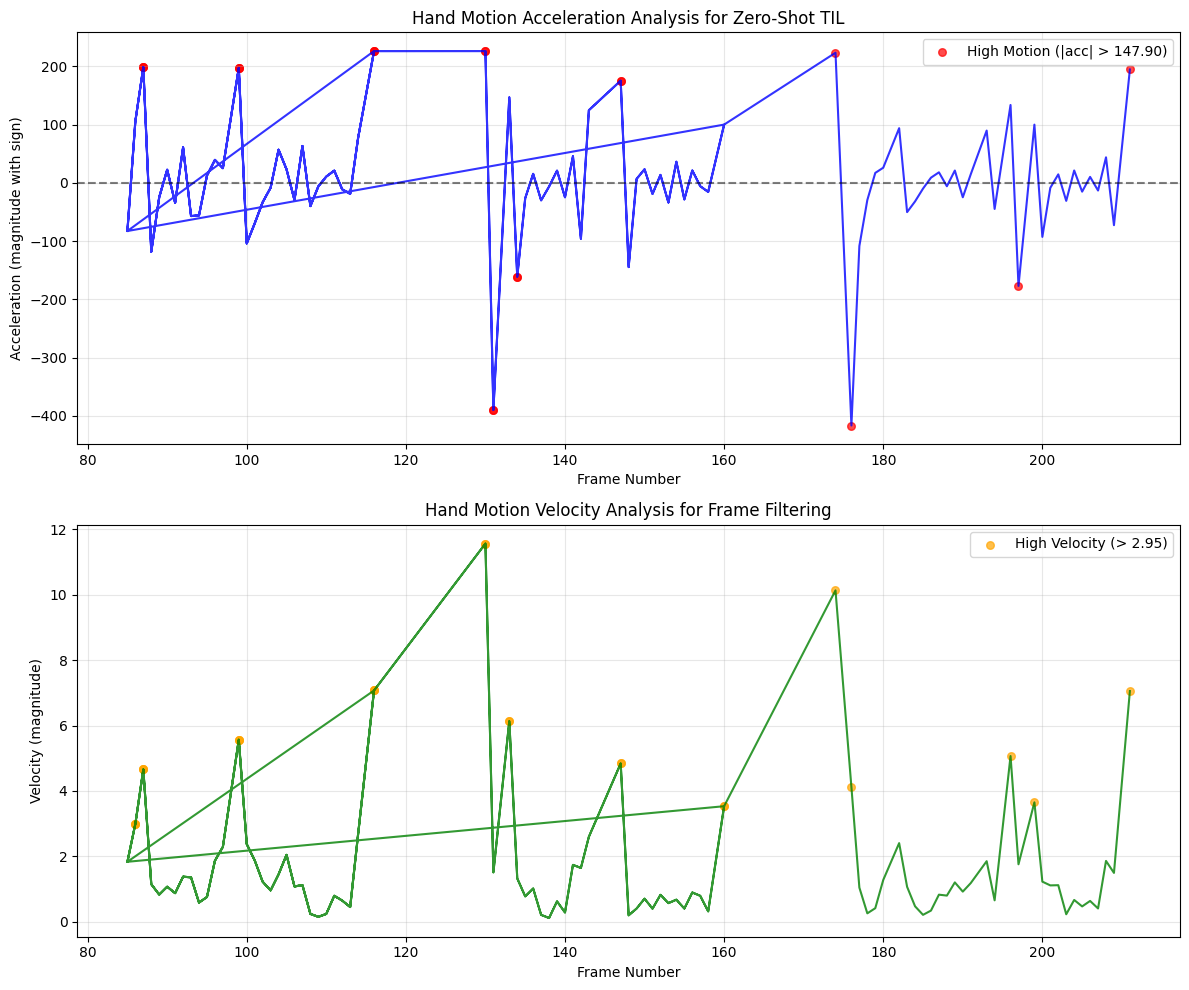


=== Frame Filtering Insights for Zero-Shot TIL ===
High-motion frames identified: 30 out of 174
Motion filtering ratio: 17.2%


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_landmarks_file(filename):
    """
    Parse the landmarks file and extract frame numbers and coordinates.
    
    Returns:
        dict: Dictionary with frame numbers as keys and coordinate dictionaries as values
    """
    landmarks_data = {}
    
    with open(filename, 'r') as file:
        content = file.read()
        
    # Split by frame markers
    frame_blocks = re.split(r'(\d+):', content)
    
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        
        # Extract x, y, z coordinates
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    
    return landmarks_data

def parse_clip_ranges(filename):
    """
    Parse clip ranges file to get segment boundaries.
    
    Returns:
        list: List of tuples containing (start_frame, end_frame)
    """
    clip_ranges = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line in lines:
        # Extract numbers from each line
        numbers = re.findall(r'\d+', line.strip())
        if len(numbers) >= 2:
            start_frame = int(numbers[0])
            end_frame = int(numbers[1])
            clip_ranges.append((start_frame, end_frame))
    
    return clip_ranges

def calculate_hand_acceleration_magnitude(landmarks, fps=30):
    """
    Calculate acceleration magnitude for 3D hand landmark positions.
    
    Args:
        landmarks: List of dictionaries with 'x', 'y', 'z' keys for each frame
        fps: Frame rate (default 30 fps for EgoPAT-3D)
    
    Returns:
        acceleration_magnitudes: List of signed acceleration magnitudes
                               (+ve = acceleration, -ve = deceleration/retardation)
        velocity_magnitudes: List of velocity magnitudes (unsigned)
    """
    if len(landmarks) < 3:
        return [], []
    
    # Convert to numpy array for vectorized operations
    positions = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    
    # Calculate time step
    dt = 1.0 / fps
    
    # First derivative: velocity = dp/dt
    velocities = np.diff(positions, axis=0) / dt
    
    # Calculate velocity magnitudes (unsigned)
    velocity_magnitudes = np.linalg.norm(velocities, axis=1)
    
    # Second derivative: acceleration = dv/dt
    accelerations = np.diff(velocities, axis=0) / dt
    
    # Calculate acceleration magnitudes
    accel_magnitudes = np.linalg.norm(accelerations, axis=1)
    
    # Determine sign: positive for acceleration, negative for retardation
    # Compare speed changes between consecutive frames
    speed_prev = np.linalg.norm(velocities[:-1], axis=1)
    speed_curr = np.linalg.norm(velocities[1:], axis=1)
    speed_change = speed_curr - speed_prev
    
    # Apply sign based on speed change
    signed_acceleration = accel_magnitudes * np.sign(speed_change)
    
    return signed_acceleration.tolist(), velocity_magnitudes.tolist()

def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """
    Process landmarks by clips, calculating velocity and acceleration for each segment.
    
    Returns:
        tuple: (all_frame_numbers, all_velocities, all_accelerations)
    """
    all_frame_numbers = []
    all_velocities = []
    all_accelerations = []
    
    for start_frame, end_frame in clip_ranges:
        # Get landmarks for this clip
        clip_frames = []
        clip_landmarks = []
        
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        
        if len(clip_landmarks) >= 3:
            # Calculate acceleration and velocity for this clip
            accelerations, velocities = calculate_hand_acceleration_magnitude(clip_landmarks, fps)
            
            # Acceleration starts from frame 2 (index 2) in the clip
            accel_frames = clip_frames[2:]  # Skip first 2 frames for acceleration
            vel_frames = clip_frames[1:]    # Skip first frame for velocity
            
            # Store results
            all_frame_numbers.extend(accel_frames)
            all_accelerations.extend(accelerations)
            
            # For velocity, we need to align with acceleration frames
            # Take velocity values that correspond to acceleration frames
            aligned_velocities = velocities[1:]  # Skip first velocity to align with acceleration
            all_velocities.extend(aligned_velocities)
    
    return all_frame_numbers, all_velocities, all_accelerations

def create_motion_analysis_plots(frame_numbers, velocities, accelerations):
    """
    Create two plots: acceleration (with sign) and velocity (magnitude only) vs frame numbers.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Acceleration (magnitude with sign)
    ax1.plot(frame_numbers, accelerations, 'b-', linewidth=1.5, alpha=0.8)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Acceleration (magnitude with sign)')
    ax1.set_title('Hand Motion Acceleration Analysis for Zero-Shot TIL')
    ax1.grid(True, alpha=0.3)
    
    # Highlight high acceleration regions
    high_accel_threshold = np.std(accelerations) * 1.5
    high_accel_indices = [i for i, acc in enumerate(accelerations) if abs(acc) > high_accel_threshold]
    if high_accel_indices:
        high_accel_frames = [frame_numbers[i] for i in high_accel_indices]
        high_accel_values = [accelerations[i] for i in high_accel_indices]
        ax1.scatter(high_accel_frames, high_accel_values, c='red', s=30, alpha=0.7, 
                   label=f'High Motion (|acc| > {high_accel_threshold:.2f})')
        ax1.legend()
    
    # Plot 2: Velocity (magnitude only)  
    ax2.plot(frame_numbers, velocities, 'g-', linewidth=1.5, alpha=0.8)
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (magnitude)')
    ax2.set_title('Hand Motion Velocity Analysis for Frame Filtering')
    ax2.grid(True, alpha=0.3)
    
    # Highlight high velocity regions
    high_vel_threshold = np.std(velocities) * 1.5
    high_vel_indices = [i for i, vel in enumerate(velocities) if vel > high_vel_threshold]
    if high_vel_indices:
        high_vel_frames = [frame_numbers[i] for i in high_vel_indices]
        high_vel_values = [velocities[i] for i in high_vel_indices]
        ax2.scatter(high_vel_frames, high_vel_values, c='orange', s=30, alpha=0.7,
                   label=f'High Velocity (> {high_vel_threshold:.2f})')
        ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def main():
    """
    Main function to execute the complete analysis pipeline.
    """
    # File paths
    landmarks_file = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    
    print("Processing landmarks by clips...")
    frame_numbers, velocities, accelerations = process_landmarks_by_clips(
        landmarks_data, clip_ranges, fps=30
    )
    
    print(f"Calculated motion data for {len(frame_numbers)} frames")
    print(f"Acceleration range: {min(accelerations):.2f} to {max(accelerations):.2f}")
    print(f"Velocity range: {min(velocities):.2f} to {max(velocities):.2f}")
    
    # Create analysis plots
    print("Creating motion analysis plots...")
    fig = create_motion_analysis_plots(frame_numbers, velocities, accelerations)
    
    # Generate frame filtering insights for zero-shot TIL
    print("\n=== Frame Filtering Insights for Zero-Shot TIL ===")
    
    # High motion frame detection
    accel_threshold = np.std(accelerations) * 1.5
    vel_threshold = np.std(velocities) * 1.5
    
    high_motion_frames = []
    for i, (frame, acc, vel) in enumerate(zip(frame_numbers, accelerations, velocities)):
        if abs(acc) > accel_threshold or vel > vel_threshold:
            high_motion_frames.append(frame)
    
    print(f"High-motion frames identified: {len(high_motion_frames)} out of {len(frame_numbers)}")
    print(f"Motion filtering ratio: {len(high_motion_frames)/len(frame_numbers)*100:.1f}%")
    
    # Return results for further analysis
    return {
        'frame_numbers': frame_numbers,
        'velocities': velocities,
        'accelerations': accelerations,
        'high_motion_frames': high_motion_frames,
        'landmarks_data': landmarks_data,
        'clip_ranges': clip_ranges
    }

if __name__ == "__main__":
    results = main()


Loading landmark data...
Loaded 112 landmark frames
Loading clip ranges...
Loaded 4 clip segments
Processing landmarks by clips...
Processed 3 clips with motion data
Clip 1 (2-127): 30 frames
Clip 2 (3-172): 56 frames
Clip 3 (4-223): 88 frames
Creating disjoint motion analysis plots...


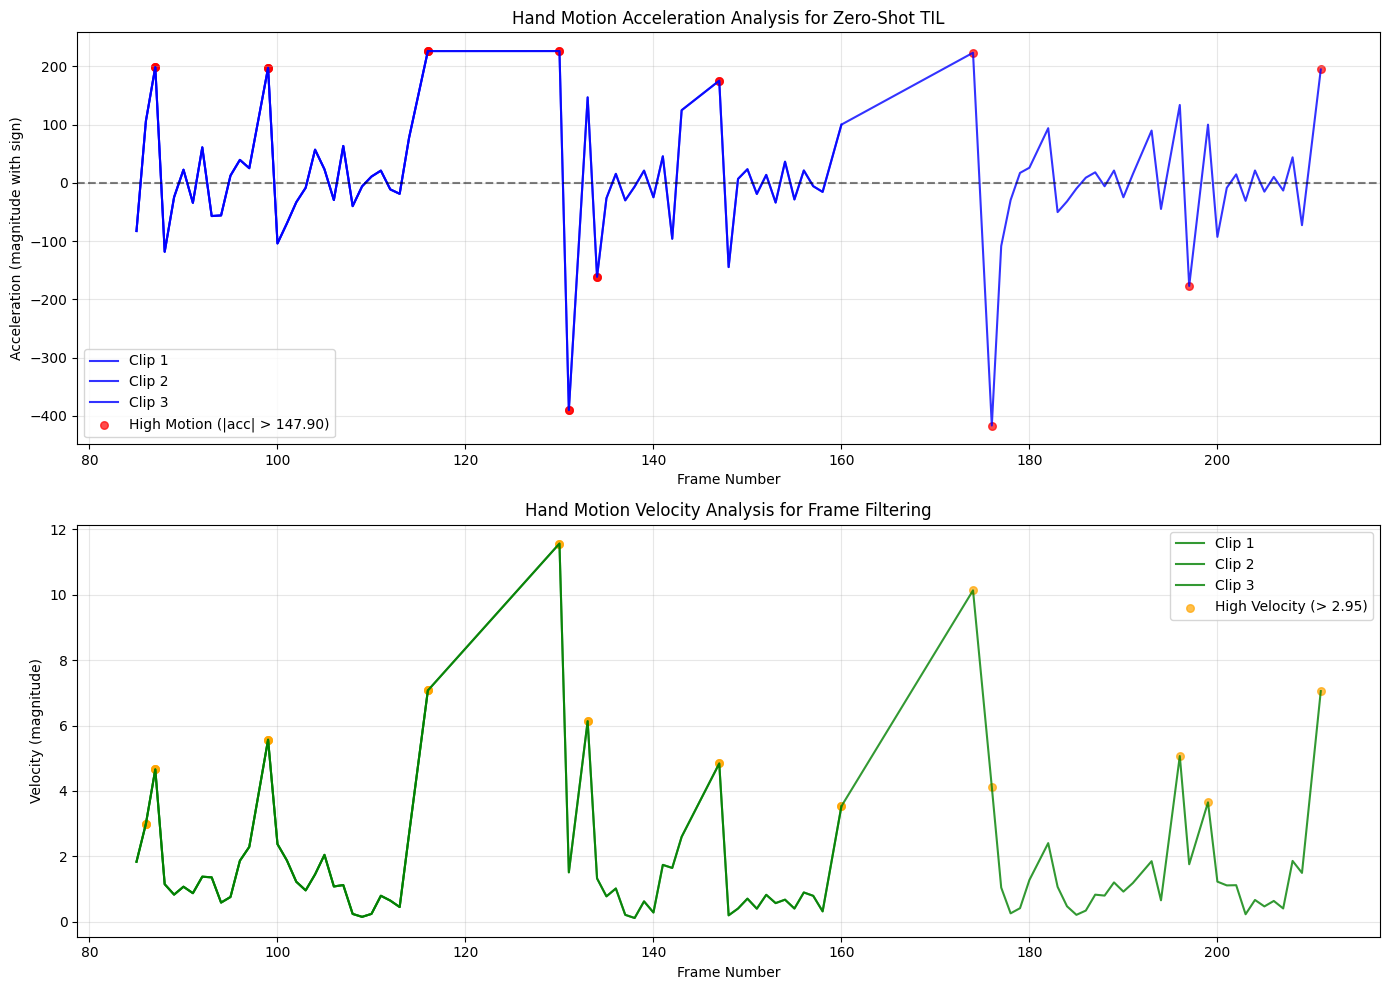


=== Zero-Shot TIL Frame Filtering Insights ===
Total frames analyzed: 174
High-motion frames: 30
Motion filtering ratio: 17.2%
Acceleration range: -416.33 to 226.04
Velocity range: 0.11 to 11.57


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_landmarks_file(filename):
    """Parse the landmarks file and extract frame numbers and coordinates."""
    landmarks_data = {}
    
    with open(filename, 'r') as file:
        content = file.read()
        
    frame_blocks = re.split(r'(\d+):', content)
    
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    
    return landmarks_data

def parse_clip_ranges(filename):
    """Parse clip ranges file to get segment boundaries."""
    clip_ranges = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line in lines:
        numbers = re.findall(r'\d+', line.strip())
        if len(numbers) >= 2:
            start_frame = int(numbers[0])
            end_frame = int(numbers[1])
            clip_ranges.append((start_frame, end_frame))
    
    return clip_ranges

def calculate_hand_acceleration_magnitude(landmarks, fps=30):
    """Calculate acceleration and velocity magnitudes for 3D hand landmark positions."""
    if len(landmarks) < 3:
        return [], []
    
    positions = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    dt = 1.0 / fps
    
    # Calculate velocity
    velocities = np.diff(positions, axis=0) / dt
    velocity_magnitudes = np.linalg.norm(velocities, axis=1)
    
    # Calculate acceleration
    accelerations = np.diff(velocities, axis=0) / dt
    accel_magnitudes = np.linalg.norm(accelerations, axis=1)
    
    # Determine sign for acceleration
    speed_prev = np.linalg.norm(velocities[:-1], axis=1)
    speed_curr = np.linalg.norm(velocities[1:], axis=1)
    speed_change = speed_curr - speed_prev
    signed_acceleration = accel_magnitudes * np.sign(speed_change)
    
    return signed_acceleration.tolist(), velocity_magnitudes.tolist()

def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """Process landmarks by clips, returning data organized by clips."""
    clip_data = []
    
    for start_frame, end_frame in clip_ranges:
        clip_frames = []
        clip_landmarks = []
        
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        
        if len(clip_landmarks) >= 3:
            accelerations, velocities = calculate_hand_acceleration_magnitude(clip_landmarks, fps)
            
            # Acceleration starts from frame 2 in the clip
            accel_frames = clip_frames[2:]
            # Align velocities with acceleration frames
            aligned_velocities = velocities[1:]
            
            clip_data.append({
                'frames': accel_frames,
                'velocities': aligned_velocities,
                'accelerations': accelerations,
                'clip_range': (start_frame, end_frame)
            })
    
    return clip_data

def create_disjoint_motion_plots(clip_data):
    """Create disjoint plots for each clip segment."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot acceleration with disjoint segments
    all_accelerations = []
    for i, clip in enumerate(clip_data):
        ax1.plot(clip['frames'], clip['accelerations'], 'b-', 
                linewidth=1.5, alpha=0.8, label=f'Clip {i+1}' if i < 3 else "")
        all_accelerations.extend(clip['accelerations'])
    
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Acceleration (magnitude with sign)')
    ax1.set_title('Hand Motion Acceleration Analysis for Zero-Shot TIL')
    ax1.grid(True, alpha=0.3)
    
    # Highlight high acceleration regions
    if all_accelerations:
        high_accel_threshold = np.std(all_accelerations) * 1.5
        for clip in clip_data:
            high_indices = [i for i, acc in enumerate(clip['accelerations']) 
                          if abs(acc) > high_accel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['accelerations'][i] for i in high_indices]
                ax1.scatter(high_frames, high_values, c='red', s=30, alpha=0.7)
        
        # Add legend only once
        ax1.scatter([], [], c='red', s=30, alpha=0.7, 
                   label=f'High Motion (|acc| > {high_accel_threshold:.2f})')
        ax1.legend()
    
    # Plot velocity with disjoint segments
    all_velocities = []
    for i, clip in enumerate(clip_data):
        ax2.plot(clip['frames'], clip['velocities'], 'g-', 
                linewidth=1.5, alpha=0.8, label=f'Clip {i+1}' if i < 3 else "")
        all_velocities.extend(clip['velocities'])
    
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (magnitude)')
    ax2.set_title('Hand Motion Velocity Analysis for Frame Filtering')
    ax2.grid(True, alpha=0.3)
    
    # Highlight high velocity regions
    if all_velocities:
        high_vel_threshold = np.std(all_velocities) * 1.5
        for clip in clip_data:
            high_indices = [i for i, vel in enumerate(clip['velocities']) 
                          if vel > high_vel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['velocities'][i] for i in high_indices]
                ax2.scatter(high_frames, high_values, c='orange', s=30, alpha=0.7)
        
        # Add legend only once
        ax2.scatter([], [], c='orange', s=30, alpha=0.7,
                   label=f'High Velocity (> {high_vel_threshold:.2f})')
        ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def main():
    """Main function with disjoint plotting."""
    landmarks_file = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    
    print("Processing landmarks by clips...")
    clip_data = process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30)
    
    print(f"Processed {len(clip_data)} clips with motion data")
    
    # Print clip statistics
    for i, clip in enumerate(clip_data):
        print(f"Clip {i+1} ({clip['clip_range'][0]}-{clip['clip_range'][1]}): "
              f"{len(clip['frames'])} frames")
    
    # Create disjoint plots
    print("Creating disjoint motion analysis plots...")
    fig = create_disjoint_motion_plots(clip_data)
    
    # Generate insights for zero-shot TIL
    print("\n=== Zero-Shot TIL Frame Filtering Insights ===")
    
    total_frames = sum(len(clip['frames']) for clip in clip_data)
    all_accelerations = [acc for clip in clip_data for acc in clip['accelerations']]
    all_velocities = [vel for clip in clip_data for vel in clip['velocities']]
    
    if all_accelerations and all_velocities:
        accel_threshold = np.std(all_accelerations) * 1.5
        vel_threshold = np.std(all_velocities) * 1.5
        
        high_motion_count = 0
        for clip in clip_data:
            for acc, vel in zip(clip['accelerations'], clip['velocities']):
                if abs(acc) > accel_threshold or vel > vel_threshold:
                    high_motion_count += 1
        
        print(f"Total frames analyzed: {total_frames}")
        print(f"High-motion frames: {high_motion_count}")
        print(f"Motion filtering ratio: {high_motion_count/total_frames*100:.1f}%")
        print(f"Acceleration range: {min(all_accelerations):.2f} to {max(all_accelerations):.2f}")
        print(f"Velocity range: {min(all_velocities):.2f} to {max(all_velocities):.2f}")
    
    return clip_data

if __name__ == "__main__":
    results = main()


Loading landmark data...
Loaded 112 landmark frames
Loading clip ranges...
Loaded 4 clip segments

=== Corrected Clip Ranges ===
Clip 1 (79-120): 42 frames
Clip 2 (127-164): 38 frames
Clip 3 (172-215): 44 frames
Clip 4 (223-262): 40 frames

Processing landmarks by clips...

Processed 4 clips with motion data
Clip 1 (79-120): 30 frames with motion data
Clip 2 (127-164): 24 frames with motion data
Clip 3 (172-215): 30 frames with motion data
Clip 4 (223-262): 20 frames with motion data

Creating disjoint motion analysis plots...


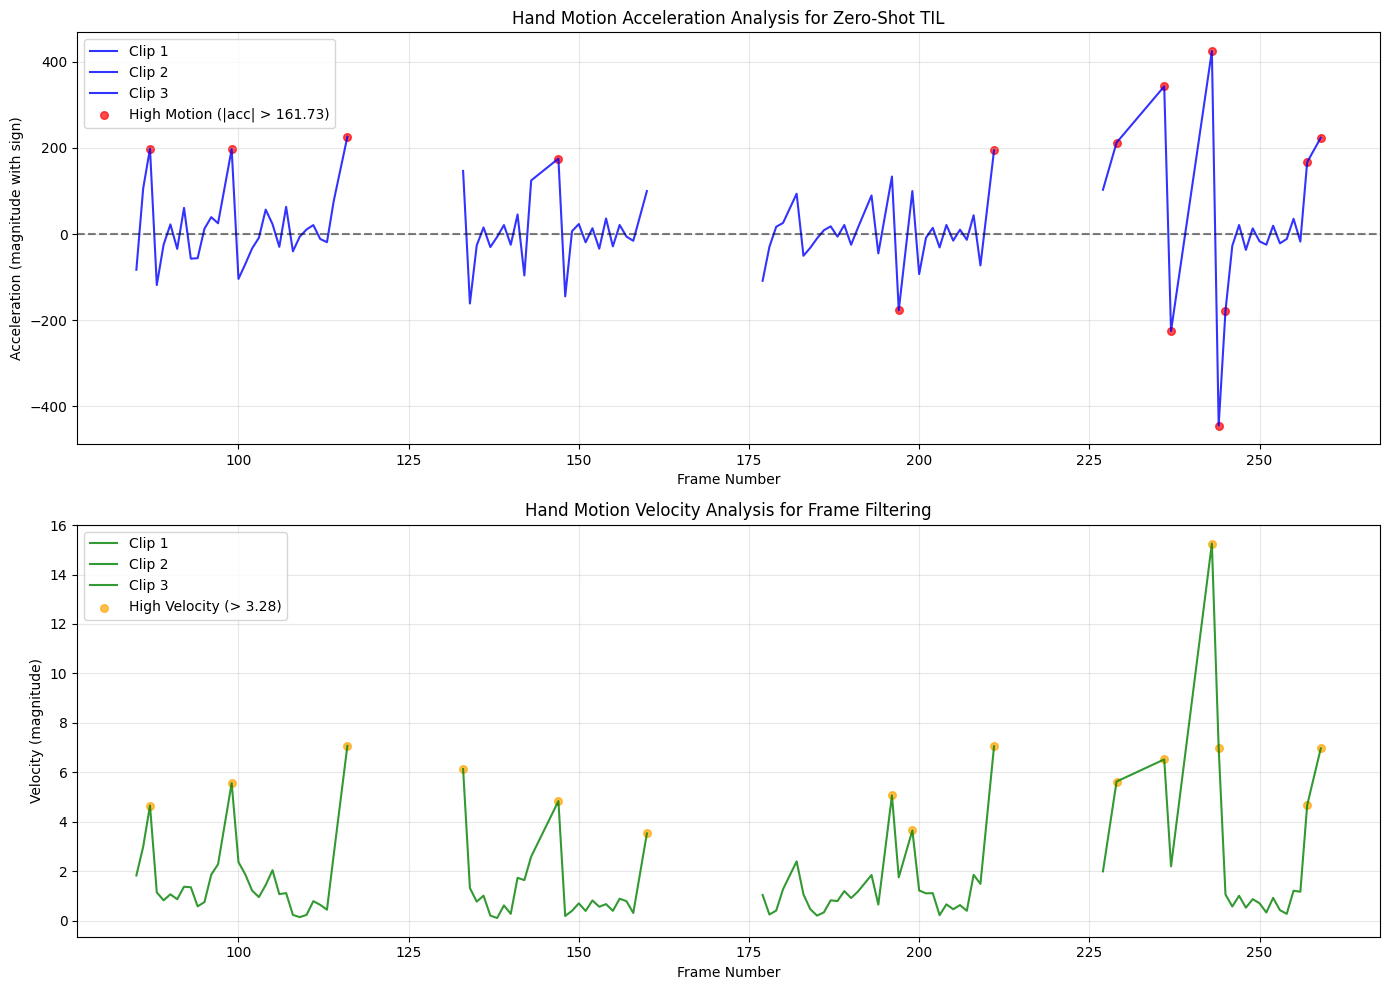


=== Zero-Shot TIL Frame Filtering Insights ===
Total frames analyzed: 104
High-motion frames: 18
Motion filtering ratio: 17.3%
Acceleration range: -444.19 to 424.75
Velocity range: 0.11 to 15.25


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_landmarks_file(filename):
    """Parse the landmarks file and extract frame numbers and coordinates."""
    landmarks_data = {}
    
    with open(filename, 'r') as file:
        content = file.read()
        
    frame_blocks = re.split(r'(\d+):', content)
    
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    
    return landmarks_data

def parse_clip_ranges(filename):
    """
    Parse clip ranges file to get segment boundaries.
    CORRECTED: Properly extracts start and end frame numbers, ignoring line indices.
    """
    clip_ranges = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line in lines:
        # Use regex to match pattern: "number. start_frame, end_frame"
        # This ignores the line index and captures only the frame range
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            start_frame = int(match.group(1))
            end_frame = int(match.group(2))
            clip_ranges.append((start_frame, end_frame))
    
    return clip_ranges

def calculate_hand_acceleration_magnitude(landmarks, fps=30):
    """Calculate acceleration and velocity magnitudes for 3D hand landmark positions."""
    if len(landmarks) < 3:
        return [], []
    
    positions = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    dt = 1.0 / fps
    
    # Calculate velocity
    velocities = np.diff(positions, axis=0) / dt
    velocity_magnitudes = np.linalg.norm(velocities, axis=1)
    
    # Calculate acceleration
    accelerations = np.diff(velocities, axis=0) / dt
    accel_magnitudes = np.linalg.norm(accelerations, axis=1)
    
    # Determine sign for acceleration
    speed_prev = np.linalg.norm(velocities[:-1], axis=1)
    speed_curr = np.linalg.norm(velocities[1:], axis=1)
    speed_change = speed_curr - speed_prev
    signed_acceleration = accel_magnitudes * np.sign(speed_change)
    
    return signed_acceleration.tolist(), velocity_magnitudes.tolist()

def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """Process landmarks by clips, returning data organized by clips."""
    clip_data = []
    
    for start_frame, end_frame in clip_ranges:
        clip_frames = []
        clip_landmarks = []
        
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        
        if len(clip_landmarks) >= 3:
            accelerations, velocities = calculate_hand_acceleration_magnitude(clip_landmarks, fps)
            
            # Acceleration starts from frame 2 in the clip
            accel_frames = clip_frames[2:]
            # Align velocities with acceleration frames
            aligned_velocities = velocities[1:]
            
            clip_data.append({
                'frames': accel_frames,
                'velocities': aligned_velocities,
                'accelerations': accelerations,
                'clip_range': (start_frame, end_frame)
            })
    
    return clip_data

def create_disjoint_motion_plots(clip_data):
    """Create disjoint plots for each clip segment."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot acceleration with disjoint segments
    all_accelerations = []
    for i, clip in enumerate(clip_data):
        ax1.plot(clip['frames'], clip['accelerations'], 'b-', 
                linewidth=1.5, alpha=0.8, label=f'Clip {i+1}' if i < 3 else "")
        all_accelerations.extend(clip['accelerations'])
    
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Acceleration (magnitude with sign)')
    ax1.set_title('Hand Motion Acceleration Analysis for Zero-Shot TIL')
    ax1.grid(True, alpha=0.3)
    
    # Highlight high acceleration regions
    if all_accelerations:
        high_accel_threshold = np.std(all_accelerations) * 1.5
        for clip in clip_data:
            high_indices = [i for i, acc in enumerate(clip['accelerations']) 
                          if abs(acc) > high_accel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['accelerations'][i] for i in high_indices]
                ax1.scatter(high_frames, high_values, c='red', s=30, alpha=0.7)
        
        # Add legend only once
        ax1.scatter([], [], c='red', s=30, alpha=0.7, 
                   label=f'High Motion (|acc| > {high_accel_threshold:.2f})')
        ax1.legend()
    
    # Plot velocity with disjoint segments
    all_velocities = []
    for i, clip in enumerate(clip_data):
        ax2.plot(clip['frames'], clip['velocities'], 'g-', 
                linewidth=1.5, alpha=0.8, label=f'Clip {i+1}' if i < 3 else "")
        all_velocities.extend(clip['velocities'])
    
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (magnitude)')
    ax2.set_title('Hand Motion Velocity Analysis for Frame Filtering')
    ax2.grid(True, alpha=0.3)
    
    # Highlight high velocity regions
    if all_velocities:
        high_vel_threshold = np.std(all_velocities) * 1.5
        for clip in clip_data:
            high_indices = [i for i, vel in enumerate(clip['velocities']) 
                          if vel > high_vel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['velocities'][i] for i in high_indices]
                ax2.scatter(high_frames, high_values, c='orange', s=30, alpha=0.7)
        
        # Add legend only once
        ax2.scatter([], [], c='orange', s=30, alpha=0.7,
                   label=f'High Velocity (> {high_vel_threshold:.2f})')
        ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def main():
    """Main function with corrected clip range parsing."""
    landmarks_file = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    
    # Print corrected clip ranges for verification
    print("\n=== Corrected Clip Ranges ===")
    for i, (start, end) in enumerate(clip_ranges):
        print(f"Clip {i+1} ({start}-{end}): {end - start + 1} frames")
    
    print("\nProcessing landmarks by clips...")
    clip_data = process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30)
    
    print(f"\nProcessed {len(clip_data)} clips with motion data")
    
    # Print actual processing results
    for i, clip in enumerate(clip_data):
        print(f"Clip {i+1} ({clip['clip_range'][0]}-{clip['clip_range'][1]}): "
              f"{len(clip['frames'])} frames with motion data")
    
    # Create disjoint plots
    print("\nCreating disjoint motion analysis plots...")
    fig = create_disjoint_motion_plots(clip_data)
    
    # Generate insights for zero-shot TIL
    print("\n=== Zero-Shot TIL Frame Filtering Insights ===")
    
    total_frames = sum(len(clip['frames']) for clip in clip_data)
    all_accelerations = [acc for clip in clip_data for acc in clip['accelerations']]
    all_velocities = [vel for clip in clip_data for vel in clip['velocities']]
    
    if all_accelerations and all_velocities:
        accel_threshold = np.std(all_accelerations) * 1.5
        vel_threshold = np.std(all_velocities) * 1.5
        
        high_motion_count = 0
        for clip in clip_data:
            for acc, vel in zip(clip['accelerations'], clip['velocities']):
                if abs(acc) > accel_threshold or vel > vel_threshold:
                    high_motion_count += 1
        
        print(f"Total frames analyzed: {total_frames}")
        print(f"High-motion frames: {high_motion_count}")
        print(f"Motion filtering ratio: {high_motion_count/total_frames*100:.1f}%")
        print(f"Acceleration range: {min(all_accelerations):.2f} to {max(all_accelerations):.2f}")
        print(f"Velocity range: {min(all_velocities):.2f} to {max(all_velocities):.2f}")
    
    return clip_data

if __name__ == "__main__":
    results = main()


Loading landmark data...
Loaded 164 landmark frames
Loading clip ranges...
Loaded 8 clip segments
Loading contact/separation annotations...
Loaded 8 contact/separation pairs

=== Clip Ranges ===
Clip 1 (79-120): 42 frames
Clip 2 (127-164): 38 frames
Clip 3 (172-215): 44 frames
Clip 4 (223-262): 40 frames
Clip 5 (272-309): 38 frames
Clip 6 (321-353): 33 frames
Clip 7 (363-402): 40 frames
Clip 8 (408-450): 43 frames

=== Contact/Separation Annotations ===
Clip 1: Contact at frame 92, Separation at frame 111
Clip 2: Contact at frame 137, Separation at frame 155
Clip 3: Contact at frame 179, Separation at frame 206
Clip 4: Contact at frame 231, Separation at frame 251
Clip 5: Contact at frame 282, Separation at frame 303
Clip 6: Contact at frame 331, Separation at frame 344
Clip 7: Contact at frame 370, Separation at frame 392
Clip 8: Contact at frame 417, Separation at frame 442

Processing landmarks by clips...

Processed 6 clips with motion data
Clip 1 (79-120): 30 frames with motion da

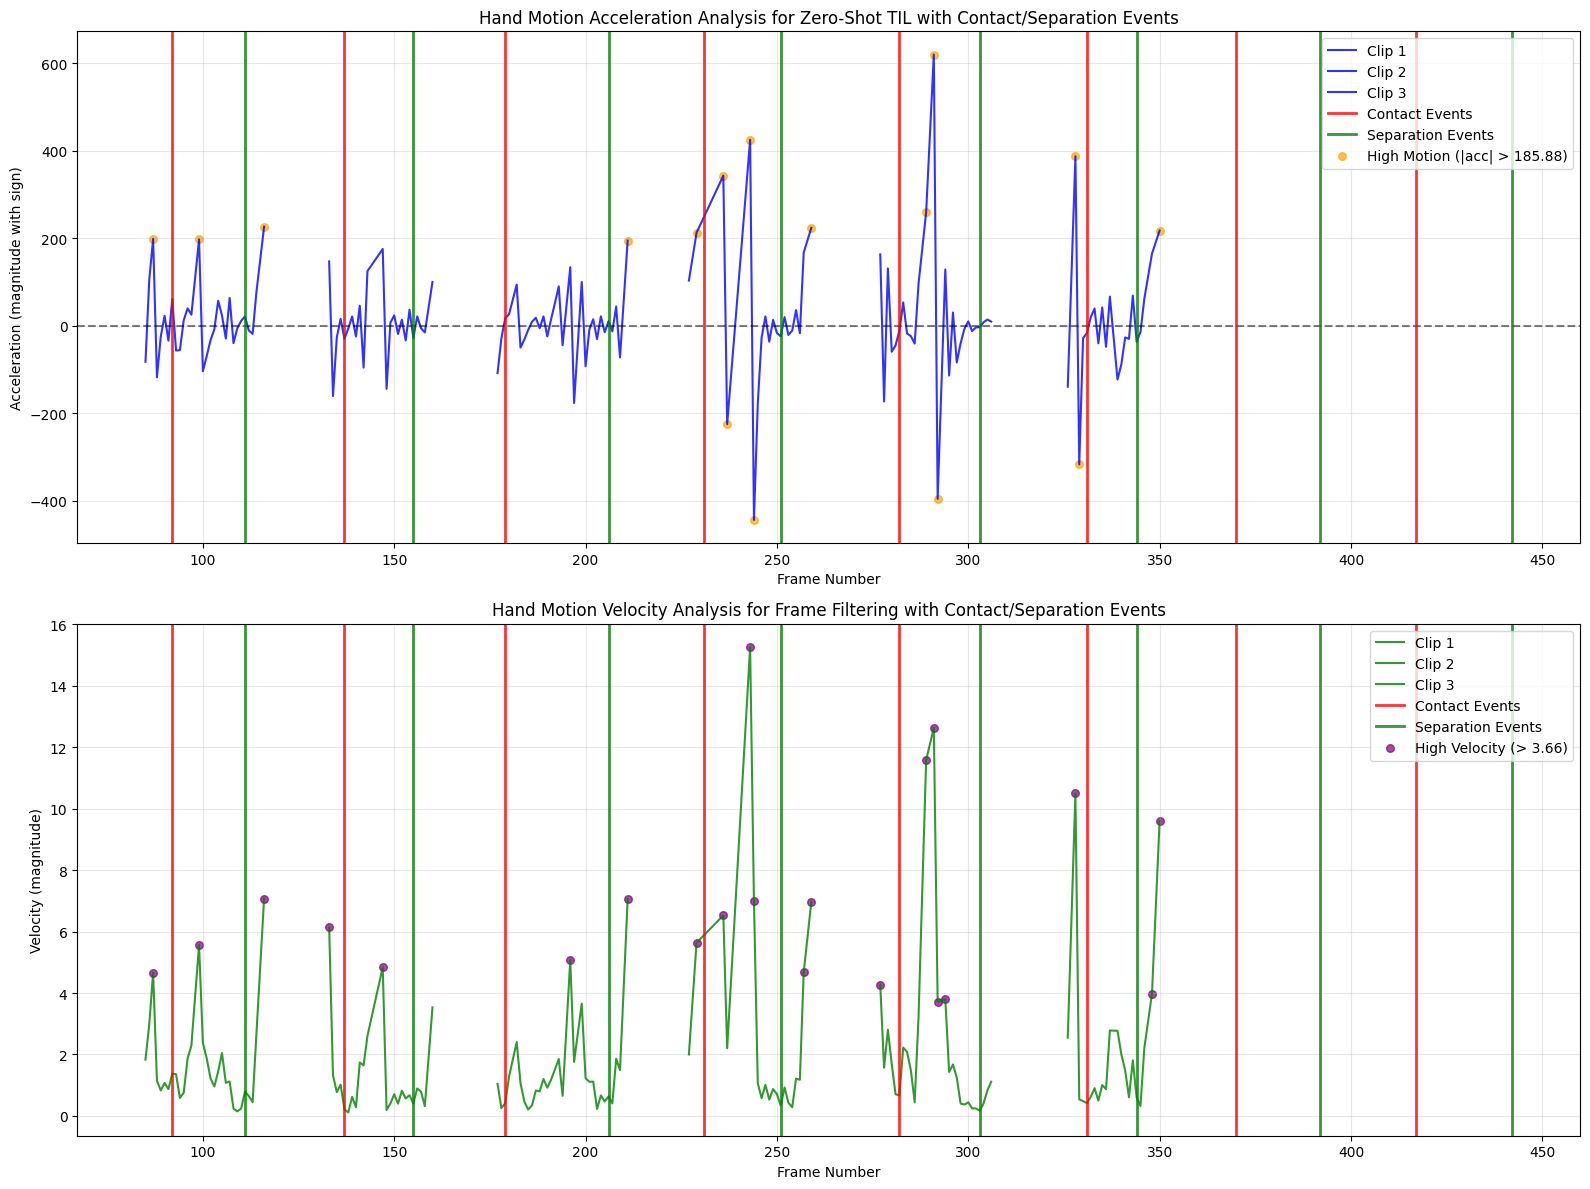


=== Zero-Shot TIL Frame Filtering Insights with Contact/Separation Analysis ===
Total frames analyzed: 152
High-motion frames: 23
Motion filtering ratio: 15.1%
Acceleration range: -444.19 to 619.45
Velocity range: 0.11 to 15.25

=== Contact/Separation Event Analysis ===
Clip 1: Contact-to-Separation duration = 19 frames
Clip 2: Contact-to-Separation duration = 18 frames
Clip 3: Contact-to-Separation duration = 27 frames
Clip 4: Contact-to-Separation duration = 20 frames
Clip 5: Contact-to-Separation duration = 21 frames
Clip 6: Contact-to-Separation duration = 13 frames
Clip 7: Contact-to-Separation duration = 22 frames
Clip 8: Contact-to-Separation duration = 25 frames


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_landmarks_file(filename):
    """Parse the landmarks file and extract frame numbers and coordinates."""
    landmarks_data = {}
    
    with open(filename, 'r') as file:
        content = file.read()
        
    frame_blocks = re.split(r'(\d+):', content)
    
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    
    return landmarks_data

def parse_clip_ranges(filename):
    """Parse clip ranges file to get segment boundaries."""
    clip_ranges = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line in lines:
        # Use regex to match pattern: "number. start_frame, end_frame"
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            start_frame = int(match.group(1))
            end_frame = int(match.group(2))
            clip_ranges.append((start_frame, end_frame))
    
    return clip_ranges

def parse_cs_annot(filename):
    """
    Parse contact and separation annotations file.
    
    Returns:
        list: List of tuples containing (contact_frame, separation_frame) for each clip
    """
    cs_annotations = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line in lines:
        # Match pattern "index. contact, separation"
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            contact = int(match.group(1))
            separation = int(match.group(2))
            cs_annotations.append((contact, separation))
    
    return cs_annotations

def calculate_hand_acceleration_magnitude(landmarks, fps=30):
    """Calculate acceleration and velocity magnitudes for 3D hand landmark positions."""
    if len(landmarks) < 3:
        return [], []
    
    positions = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    dt = 1.0 / fps
    
    # Calculate velocity
    velocities = np.diff(positions, axis=0) / dt
    velocity_magnitudes = np.linalg.norm(velocities, axis=1)
    
    # Calculate acceleration
    accelerations = np.diff(velocities, axis=0) / dt
    accel_magnitudes = np.linalg.norm(accelerations, axis=1)
    
    # Determine sign for acceleration
    speed_prev = np.linalg.norm(velocities[:-1], axis=1)
    speed_curr = np.linalg.norm(velocities[1:], axis=1)
    speed_change = speed_curr - speed_prev
    signed_acceleration = accel_magnitudes * np.sign(speed_change)
    
    return signed_acceleration.tolist(), velocity_magnitudes.tolist()

def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """Process landmarks by clips, returning data organized by clips."""
    clip_data = []
    
    for start_frame, end_frame in clip_ranges:
        clip_frames = []
        clip_landmarks = []
        
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        
        if len(clip_landmarks) >= 3:
            accelerations, velocities = calculate_hand_acceleration_magnitude(clip_landmarks, fps)
            
            # Acceleration starts from frame 2 in the clip
            accel_frames = clip_frames[2:]
            # Align velocities with acceleration frames
            aligned_velocities = velocities[1:]
            
            clip_data.append({
                'frames': accel_frames,
                'velocities': aligned_velocities,
                'accelerations': accelerations,
                'clip_range': (start_frame, end_frame)
            })
    
    return clip_data

def create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations):
    """
    Create disjoint plots for each clip segment with contact/separation annotations.
    
    Args:
        clip_data: List of clip motion data
        cs_annotations: List of (contact_frame, separation_frame) tuples
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # Plot acceleration with disjoint segments
    all_accelerations = []
    for i, clip in enumerate(clip_data):
        ax1.plot(clip['frames'], clip['accelerations'], 'b-', 
                linewidth=1.5, alpha=0.8, label=f'Clip {i+1}' if i < 3 else "")
        all_accelerations.extend(clip['accelerations'])
    
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Acceleration (magnitude with sign)')
    ax1.set_title('Hand Motion Acceleration Analysis for Zero-Shot TIL with Contact/Separation Events')
    ax1.grid(True, alpha=0.3)
    
    # Add contact and separation vertical lines for acceleration plot
    for i, (contact, separation) in enumerate(cs_annotations):
        if i == 0:  # Add labels only once for legend
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2, 
                       label='Contact Events')
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2, 
                       label='Separation Events')
        else:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    # Highlight high acceleration regions
    if all_accelerations:
        high_accel_threshold = np.std(all_accelerations) * 1.5
        for clip in clip_data:
            high_indices = [i for i, acc in enumerate(clip['accelerations']) 
                          if abs(acc) > high_accel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['accelerations'][i] for i in high_indices]
                ax1.scatter(high_frames, high_values, c='orange', s=30, alpha=0.7)
        
        # Add legend entries
        ax1.scatter([], [], c='orange', s=30, alpha=0.7, 
                   label=f'High Motion (|acc| > {high_accel_threshold:.2f})')
        ax1.legend(loc='upper right')
    
    # Plot velocity with disjoint segments
    all_velocities = []
    for i, clip in enumerate(clip_data):
        ax2.plot(clip['frames'], clip['velocities'], 'g-', 
                linewidth=1.5, alpha=0.8, label=f'Clip {i+1}' if i < 3 else "")
        all_velocities.extend(clip['velocities'])
    
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (magnitude)')
    ax2.set_title('Hand Motion Velocity Analysis for Frame Filtering with Contact/Separation Events')
    ax2.grid(True, alpha=0.3)
    
    # Add contact and separation vertical lines for velocity plot
    for i, (contact, separation) in enumerate(cs_annotations):
        if i == 0:  # Add labels only once for legend
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2, 
                       label='Contact Events')
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2, 
                       label='Separation Events')
        else:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    # Highlight high velocity regions
    if all_velocities:
        high_vel_threshold = np.std(all_velocities) * 1.5
        for clip in clip_data:
            high_indices = [i for i, vel in enumerate(clip['velocities']) 
                          if vel > high_vel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['velocities'][i] for i in high_indices]
                ax2.scatter(high_frames, high_values, c='purple', s=30, alpha=0.7)
        
        # Add legend entries
        ax2.scatter([], [], c='purple', s=30, alpha=0.7,
                   label=f'High Velocity (> {high_vel_threshold:.2f})')
        ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig

def main():
    """Main function with contact/separation annotations."""
    landmarks_file = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    cs_annot_file = "../test_data/cs_annot.txt"
    
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    
    print("Loading contact/separation annotations...")
    cs_annotations = parse_cs_annot(cs_annot_file)
    print(f"Loaded {len(cs_annotations)} contact/separation pairs")
    
    # Print clip ranges for verification
    print("\n=== Clip Ranges ===")
    for i, (start, end) in enumerate(clip_ranges):
        print(f"Clip {i+1} ({start}-{end}): {end - start + 1} frames")
    
    # Print contact/separation annotations
    print("\n=== Contact/Separation Annotations ===")
    for i, (contact, separation) in enumerate(cs_annotations):
        print(f"Clip {i+1}: Contact at frame {contact}, Separation at frame {separation}")
    
    print("\nProcessing landmarks by clips...")
    clip_data = process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30)
    
    print(f"\nProcessed {len(clip_data)} clips with motion data")
    
    # Print actual processing results
    for i, clip in enumerate(clip_data):
        print(f"Clip {i+1} ({clip['clip_range'][0]}-{clip['clip_range'][1]}): "
              f"{len(clip['frames'])} frames with motion data")
    
    # Create enhanced plots with contact/separation annotations
    print("\nCreating motion analysis plots with contact/separation annotations...")
    fig = create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations)
    
    # Generate enhanced insights for zero-shot TIL research
    print("\n=== Zero-Shot TIL Frame Filtering Insights with Contact/Separation Analysis ===")
    
    total_frames = sum(len(clip['frames']) for clip in clip_data)
    all_accelerations = [acc for clip in clip_data for acc in clip['accelerations']]
    all_velocities = [vel for clip in clip_data for vel in clip['velocities']]
    
    if all_accelerations and all_velocities:
        accel_threshold = np.std(all_accelerations) * 1.5
        vel_threshold = np.std(all_velocities) * 1.5
        
        high_motion_count = 0
        for clip in clip_data:
            for acc, vel in zip(clip['accelerations'], clip['velocities']):
                if abs(acc) > accel_threshold or vel > vel_threshold:
                    high_motion_count += 1
        
        print(f"Total frames analyzed: {total_frames}")
        print(f"High-motion frames: {high_motion_count}")
        print(f"Motion filtering ratio: {high_motion_count/total_frames*100:.1f}%")
        print(f"Acceleration range: {min(all_accelerations):.2f} to {max(all_accelerations):.2f}")
        print(f"Velocity range: {min(all_velocities):.2f} to {max(all_velocities):.2f}")
        
        # Analyze motion patterns around contact/separation events
        print(f"\n=== Contact/Separation Event Analysis ===")
        for i, (contact, separation) in enumerate(cs_annotations):
            print(f"Clip {i+1}: Contact-to-Separation duration = {separation - contact} frames")
    
    return {
        'clip_data': clip_data,
        'cs_annotations': cs_annotations,
        'landmarks_data': landmarks_data,
        'clip_ranges': clip_ranges
    }

if __name__ == "__main__":
    results = main()


Loading landmark data...
Loaded 212 landmark frames
Loading clip ranges...
Loaded 8 clip segments
Loading contact/separation annotations...
Loaded 8 contact/separation pairs

=== Annotation Validation ===
Clip ranges: 8 entries
CS annotations: 8 entries
✅ Clip 1: Contact 92, Separation 111 (within 79-120)
✅ Clip 2: Contact 137, Separation 155 (within 127-164)
✅ Clip 3: Contact 179, Separation 206 (within 172-215)
✅ Clip 4: Contact 231, Separation 251 (within 223-262)
✅ Clip 5: Contact 282, Separation 303 (within 272-309)
✅ Clip 6: Contact 331, Separation 344 (within 321-353)
✅ Clip 7: Contact 370, Separation 392 (within 363-402)
✅ Clip 8: Contact 417, Separation 442 (within 408-450)

Processing landmarks by clips...
Clip 1 (79-120): Found 32 landmark frames
Clip 2 (127-164): Found 26 landmark frames
Clip 3 (172-215): Found 32 landmark frames
Clip 4 (223-262): Found 22 landmark frames
Clip 5 (272-309): Found 29 landmark frames
Clip 6 (321-353): Found 23 landmark frames
Clip 7 (363-402):

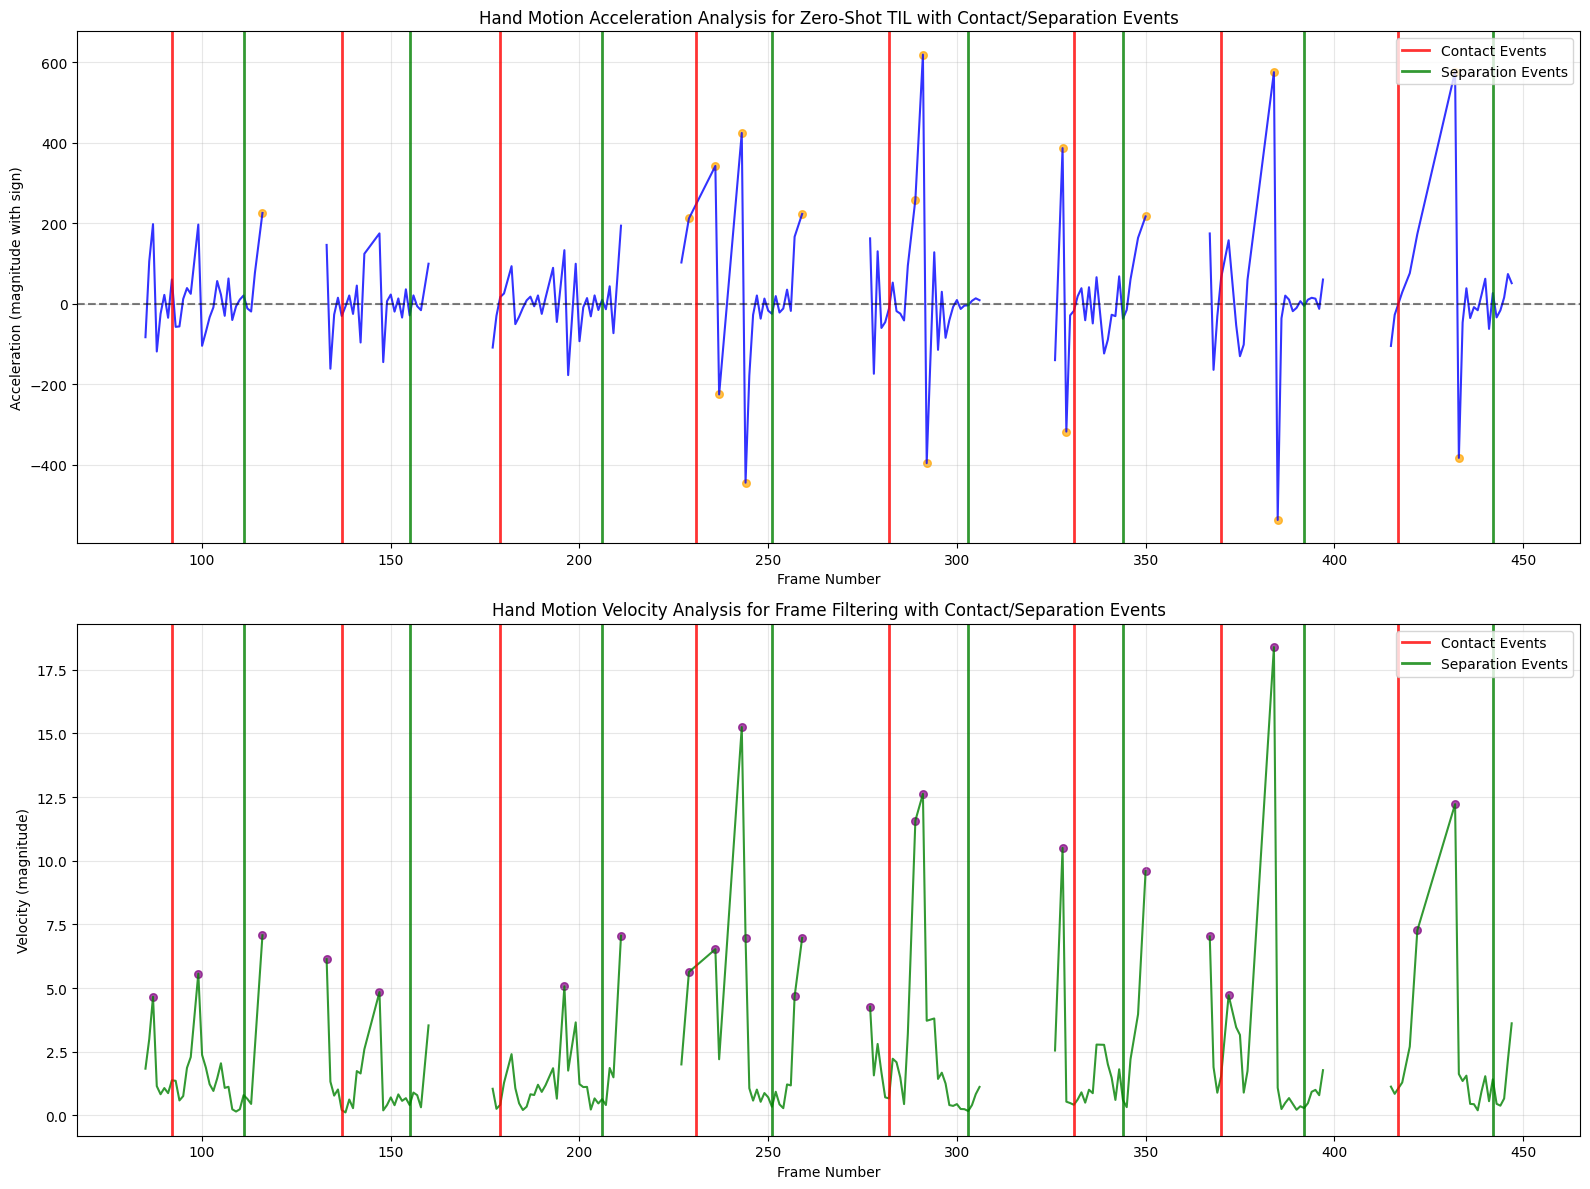


=== Acceleration-Based Frame Filtering Insights ===
Total frames analyzed: 196
Acceleration range: -536.79 to 619.45
Velocity range: 0.11 to 18.39
High-motion acceleration threshold: 204.08
High-motion velocity threshold: 4.00


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_landmarks_file(filename):
    """Parse the landmarks file and extract frame numbers and coordinates."""
    landmarks_data = {}
    
    with open(filename, 'r') as file:
        content = file.read()
        
    frame_blocks = re.split(r'(\d+):', content)
    
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    
    return landmarks_data

def parse_clip_ranges(filename):
    """Parse clip ranges file with robust error handling."""
    clip_ranges = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:  # Skip empty lines
            continue
            
        # Match pattern "number. start_frame, end_frame"
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            start_frame = int(match.group(1))
            end_frame = int(match.group(2))
            clip_ranges.append((start_frame, end_frame))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    
    return clip_ranges

def parse_cs_annot(filename):
    """Parse contact and separation annotations with robust error handling."""
    cs_annotations = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:  # Skip empty lines
            continue
            
        # Match pattern "index. contact, separation"
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            contact = int(match.group(1))
            separation = int(match.group(2))
            cs_annotations.append((contact, separation))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    
    return cs_annotations

def validate_annotations(clip_ranges, cs_annotations):
    """Validate that contact/separation frames are within clip boundaries."""
    print(f"\n=== Annotation Validation ===")
    print(f"Clip ranges: {len(clip_ranges)} entries")
    print(f"CS annotations: {len(cs_annotations)} entries")
    
    if len(clip_ranges) != len(cs_annotations):
        print(f"⚠️  MISMATCH: {len(clip_ranges)} clips vs {len(cs_annotations)} annotations")
        return False
    
    validation_passed = True
    for i, ((start, end), (contact, separation)) in enumerate(zip(clip_ranges, cs_annotations)):
        clip_num = i + 1
        
        # Check if contact is within clip range
        if not (start <= contact <= end):
            print(f"❌ Clip {clip_num}: Contact frame {contact} outside range ({start}-{end})")
            validation_passed = False
        
        # Check if separation is within clip range
        if not (start <= separation <= end):
            print(f"❌ Clip {clip_num}: Separation frame {separation} outside range ({start}-{end})")
            validation_passed = False
        
        # Check if contact comes before separation
        if contact >= separation:
            print(f"❌ Clip {clip_num}: Contact {contact} should be before separation {separation}")
            validation_passed = False
        
        if validation_passed:
            print(f"✅ Clip {clip_num}: Contact {contact}, Separation {separation} (within {start}-{end})")
    
    return validation_passed

def calculate_hand_acceleration_magnitude(landmarks, fps=30):
    """Calculate acceleration and velocity magnitudes for 3D hand landmark positions."""
    if len(landmarks) < 3:
        return [], []
    
    positions = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    dt = 1.0 / fps
    
    # Calculate velocity
    velocities = np.diff(positions, axis=0) / dt
    velocity_magnitudes = np.linalg.norm(velocities, axis=1)
    
    # Calculate acceleration
    accelerations = np.diff(velocities, axis=0) / dt
    accel_magnitudes = np.linalg.norm(accelerations, axis=1)
    
    # Determine sign for acceleration
    speed_prev = np.linalg.norm(velocities[:-1], axis=1)
    speed_curr = np.linalg.norm(velocities[1:], axis=1)
    speed_change = speed_curr - speed_prev
    signed_acceleration = accel_magnitudes * np.sign(speed_change)
    
    return signed_acceleration.tolist(), velocity_magnitudes.tolist()

def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """Process landmarks by clips, returning data organized by clips."""
    clip_data = []
    
    for clip_idx, (start_frame, end_frame) in enumerate(clip_ranges):
        clip_frames = []
        clip_landmarks = []
        
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        
        print(f"Clip {clip_idx + 1} ({start_frame}-{end_frame}): Found {len(clip_landmarks)} landmark frames")
        
        if len(clip_landmarks) >= 3:
            accelerations, velocities = calculate_hand_acceleration_magnitude(clip_landmarks, fps)
            
            # Acceleration starts from frame 2 in the clip
            accel_frames = clip_frames[2:]
            # Align velocities with acceleration frames
            aligned_velocities = velocities[1:]
            
            clip_data.append({
                'frames': accel_frames,
                'velocities': aligned_velocities,
                'accelerations': accelerations,
                'clip_range': (start_frame, end_frame),
                'clip_index': clip_idx
            })
        else:
            print(f"⚠️  Clip {clip_idx + 1}: Not enough landmarks for motion analysis")
    
    return clip_data

def create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations):
    """Create disjoint plots with ONLY contact/separation legends for zero-shot TIL research."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # Plot acceleration with disjoint segments (NO CLIP LABELS)
    all_accelerations = []
    for i, clip in enumerate(clip_data):
        ax1.plot(clip['frames'], clip['accelerations'], 'b-', 
                linewidth=1.5, alpha=0.8)  # Removed label parameter
        all_accelerations.extend(clip['accelerations'])
    
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Acceleration (magnitude with sign)')
    ax1.set_title('Hand Motion Acceleration Analysis for Zero-Shot TIL with Contact/Separation Events')
    ax1.grid(True, alpha=0.3)
    
    # Add ONLY contact and separation lines with legends
    contact_label_added = False
    separation_label_added = False
    
    # Use min length to avoid index errors
    annotation_count = min(len(clip_data), len(cs_annotations))
    print(f"\nAdding annotations for {annotation_count} clips")
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        # Add labels only once for legend
        if not contact_label_added:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                       label='Contact Events')
            contact_label_added = True
        else:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                       label='Separation Events')
            separation_label_added = True
        else:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    # Highlight high acceleration regions WITHOUT legend
    if all_accelerations:
        high_accel_threshold = np.std(all_accelerations) * 1.5
        for clip in clip_data:
            high_indices = [i for i, acc in enumerate(clip['accelerations']) 
                          if abs(acc) > high_accel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['accelerations'][i] for i in high_indices]
                ax1.scatter(high_frames, high_values, c='orange', s=30, alpha=0.7)
                # NO LEGEND ENTRY FOR HIGH MOTION
    
    # Show ONLY Contact/Separation legends
    ax1.legend(loc='upper right')
    
    # Plot velocity with disjoint segments (NO CLIP LABELS)
    all_velocities = []
    for i, clip in enumerate(clip_data):
        ax2.plot(clip['frames'], clip['velocities'], 'g-', 
                linewidth=1.5, alpha=0.8)  # Removed label parameter
        all_velocities.extend(clip['velocities'])
    
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (magnitude)')
    ax2.set_title('Hand Motion Velocity Analysis for Frame Filtering with Contact/Separation Events')
    ax2.grid(True, alpha=0.3)
    
    # Add ONLY contact and separation lines for velocity plot
    contact_label_added = False
    separation_label_added = False
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        if not contact_label_added:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                       label='Contact Events')
            contact_label_added = True
        else:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                       label='Separation Events')
            separation_label_added = True
        else:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    # Highlight high velocity regions WITHOUT legend
    if all_velocities:
        high_vel_threshold = np.std(all_velocities) * 1.5
        for clip in clip_data:
            high_indices = [i for i, vel in enumerate(clip['velocities']) 
                          if vel > high_vel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['velocities'][i] for i in high_indices]
                ax2.scatter(high_frames, high_values, c='purple', s=30, alpha=0.7)
                # NO LEGEND ENTRY FOR HIGH VELOCITY
    
    # Show ONLY Contact/Separation legends
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig


def main():
    """Main function with enhanced error handling and validation."""
    landmarks_file = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    cs_annot_file = "../test_data/cs_annot.txt"
    
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    
    print("Loading contact/separation annotations...")
    cs_annotations = parse_cs_annot(cs_annot_file)
    print(f"Loaded {len(cs_annotations)} contact/separation pairs")
    
    # Validate annotations
    validation_passed = validate_annotations(clip_ranges, cs_annotations)
    if not validation_passed:
        print("⚠️  Validation failed, but continuing with analysis...")
    
    print("\nProcessing landmarks by clips...")
    clip_data = process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30)
    
    print(f"\n=== Motion Analysis Results ===")
    for i, clip in enumerate(clip_data):
        print(f"Clip {i+1} ({clip['clip_range'][0]}-{clip['clip_range'][1]}): "
              f"{len(clip['frames'])} frames with motion data")
    
    # Create enhanced plots with annotations
    print("\n=== Creating Enhanced Plots for Zero-Shot TIL Research ===")
    fig = create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations)
    
    # Generate insights for acceleration-based frame filtering
    print("\n=== Acceleration-Based Frame Filtering Insights ===")
    
    total_frames = sum(len(clip['frames']) for clip in clip_data)
    all_accelerations = [acc for clip in clip_data for acc in clip['accelerations']]
    all_velocities = [vel for clip in clip_data for vel in clip['velocities']]
    
    if all_accelerations and all_velocities:
        accel_threshold = np.std(all_accelerations) * 1.5
        vel_threshold = np.std(all_velocities) * 1.5
        
        print(f"Total frames analyzed: {total_frames}")
        print(f"Acceleration range: {min(all_accelerations):.2f} to {max(all_accelerations):.2f}")
        print(f"Velocity range: {min(all_velocities):.2f} to {max(all_velocities):.2f}")
        print(f"High-motion acceleration threshold: {accel_threshold:.2f}")
        print(f"High-motion velocity threshold: {vel_threshold:.2f}")
    
    return {
        'clip_data': clip_data,
        'cs_annotations': cs_annotations,
        'landmarks_data': landmarks_data,
        'clip_ranges': clip_ranges,
        'validation_passed': validation_passed
    }

if __name__ == "__main__":
    results = main()
